# 线性方程组与高斯消元

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("success")

success


In [8]:
A = np.array([[2.0, 1.0], [1.0, 3.0]])
b = np.array([5.0, 5.0])

x = np.linalg.solve(A, b)
print('解 x= ', x)
print('验算 A@x=', A @ x)


解 x=  [2. 1.]
验算 A@x= [5. 5.]


### 两条直线

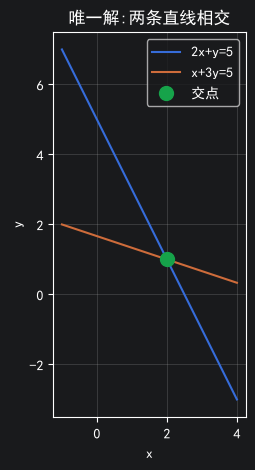

In [3]:
t = np.linspace(-1, 4, 50)
plt.figure(figsize=(6, 5))
plt.plot(t, 5 - 2 * t, label='2x+y=5')
plt.plot(t, (5 - t) / 3, label='x+3y=5')
plt.plot(x[0], x[1], 'o', color='#16a34a', markersize=10, label='交点')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('唯一解:两条直线相交')
plt.gca().set_aspect('equal')
plt.show()

### 高斯消元

In [4]:
def gauss_solve(A, b):
    n = len(b)
    M = np.hstack([A.astype(float).copy(), b.reshape(-1, 1).astype(float)])
    for k in range(n):
        i = k + int(np.argmax(np.abs(M[k:, k])))
        M[[k, i]] = M[[i, k]]
        if abs(M[k, k]) < 1e-12:
            return None, M
        for i in range(k + 1, n):
            f = M[i, k] / M[k, k]
            M[i] -= f * M[k]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (M[i, -1] - M[i, i + 1:n] @ x[i + 1:n] / M[i, i])
    return x, M


A = np.array([[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]])
b = np.array([8.0, -11.0, -3.0])
x, U = gauss_solve(A, b)
print(f'手写消元x= {x}')
print(f'numpy.slove x= {np.linalg.solve(A, b)}')
print('上三角增广矩阵')
print(np.round(U, 4))

手写消元x= [-12.60444444   4.41333333  -0.2       ]
numpy.slove x= [ 2.  3. -1.]
上三角增广矩阵
[[ -3.      -1.       2.     -11.    ]
 [  0.       1.6667   0.6667   4.3333]
 [  0.       0.       0.2     -0.2   ]]


In [5]:

def diagnose(A, b):
    x, M = gauss_solve(A, b)
    print("增广矩阵消元后")
    print(np.round(M, 4))
    if x is None:
        row = M[-1]
        if abs(row[-1]) > 1e-8:
            print('无解')
        else:
            print('有无穷多解或者需要继续看秩')
    else:
        print('唯一解:', x)


print('=====看下相交======')
diagnose(np.array([[2., 1.], [1., 3.]]), np.array([5., 5.]))

print('======平行=========')
diagnose(np.array([[1., 1.], [2., 2.]]), np.array([1., 3.]))
print('======重合无穷======')
diagnose(np.array([[1., 1.], [2., 2.]]), np.array([1., 2.]))

=====看下相交======
增广矩阵消元后
[[2.  1.  5. ]
 [0.  2.5 2.5]]
唯一解: [3.75 2.5 ]
======平行=========
增广矩阵消元后
[[ 2.   2.   3. ]
 [ 0.   0.  -0.5]]
无解
======重合无穷======
增广矩阵消元后
[[2. 2. 2.]
 [0. 0. 0.]]
有无穷多解或者需要继续看秩


### 病态: 扰动0.05

In [6]:
A = np.array([[1.0, 1.0], [1.0, 1.01]])
b0 = np.array([2.0, 2.01])
b1 = np.array([2.0, 2.06])

x0 = np.linalg.solve(A, b0)
x1 = np.linalg.solve(A, b1)
print('原解', x0)
print('扰动后', x1)
print('解的改变量', np.linalg.norm(x0 - x1))
print('cond(A)约等于', np.linalg.cond(A))

原解 [1. 1.]
扰动后 [-4.  6.]
解的改变量 7.071067811865507
cond(A)约等于 402.0075124842952


### 牛顿步就是解方程组

In [7]:
xy = np.array([1.6, 1.2])
g = np.array([2.0 * xy[0], 20.0 * xy[1]])
H = np.array([[2.0, 2.0], [0.0, 20.0]])
d = np.linalg.solve(H, -g)
print('梯度g = ', g)
print('牛顿步 d= ', d)
print('下一步 xy+d=', xy + d, '二次型应该到原点')
print('错误示范: 不要np.linalg.inv(H) @(-g),能solve 就能slove')

梯度g =  [ 3.2 24. ]
牛顿步 d=  [-0.4 -1.2]
下一步 xy+d= [1.2 0. ] 二次型应该到原点
错误示范: 不要np.linalg.inv(H) @(-g),能solve 就能slove
